In [2]:
# All the imports

import numpy as np
from skfem import MeshTri, Basis, asm, condense
from skfem.element import ElementTriP1
from skfem.models.poisson import laplace
from skfem.helpers import dot, grad
from skfem import BilinearForm, LinearForm
from skfem.utils import solve
import matplotlib.pyplot as plt
from skfem.visuals.matplotlib import plot
from scipy.sparse.linalg import eigsh, ArpackNoConvergence
import pickle
from scipy.sparse.linalg import splu, LinearOperator, eigsh
import os

In [4]:
# Load all dictionaries into Data_dict

Data_dict = {}
for D_max in [1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]:
    filename = f"Data/Data_dict_dmax_{D_max}.pkl"
    if os.path.exists(filename):
        with open(filename, "rb") as f:
            Data_dict[D_max] = pickle.load(f)
    else:
        print(f"File {filename} not found.")

In [5]:
# Computing the p values

range_end = 8
for D_max in [1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]:
    Data_dict[D_max]["chi"] = []
    for r in range(0, range_end):
        lam1 = Data_dict[D_max]["lambda1"][r]
        lam2 = Data_dict[D_max]["lambda1"][r+1]
        lam3 = Data_dict[D_max]["lambda1"][r+2]

        num = lam2 - lam1
        denom = lam3 - lam2
        chi = np.log(num/denom) / np.log(4)
        Data_dict[D_max]["chi"].append(chi)
        print(f"D_max: {D_max}, level: {r}, chi: {chi}")

D_max: 1, level: 0, chi: 1.0177005052721326
D_max: 1, level: 1, chi: 1.0047323620589697
D_max: 1, level: 2, chi: 1.0011699518699069
D_max: 1, level: 3, chi: 1.000290909812822
D_max: 1, level: 4, chi: 1.0000726018973147
D_max: 1, level: 5, chi: 1.000017960167345
D_max: 1, level: 6, chi: 1.0000043059637729
D_max: 1, level: 7, chi: 0.9999745040760889
D_max: 10, level: 0, chi: 0.5761093392474487
D_max: 10, level: 1, chi: 0.5470175874542892
D_max: 10, level: 2, chi: 0.48030923982171647
D_max: 10, level: 3, chi: 0.43054658245694377
D_max: 10, level: 4, chi: 0.406933146827985
D_max: 10, level: 5, chi: 0.39701414494626475
D_max: 10, level: 6, chi: 0.39291232138110477
D_max: 10, level: 7, chi: 0.39120392695806144
D_max: 20, level: 0, chi: 0.5721955511701744
D_max: 20, level: 1, chi: 0.5580783573173416
D_max: 20, level: 2, chi: 0.42057082635538867
D_max: 20, level: 3, chi: 0.3324863068377075
D_max: 20, level: 4, chi: 0.2987914298832302
D_max: 20, level: 5, chi: 0.28742017952868826
D_max: 20, lev

[np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
[0.98260735 0.99528993 0.99883142 0.99970917 0.9999274  0.99998204
 0.99999569 1.0000255 ]
[np.float64(2.564336260059615), np.float64(2.564336260059615), np.float64(2.564336260059615), np.float64(2.564336260059615), np.float64(2.564336260059615), np.float64(2.564336260059615), np.float64(2.564336260059615), np.float64(2.564336260059615)]
[1.73578162 1.82809479 2.08199201 2.32262905 2.45740611 2.51880194
 2.54509708 2.55621156]
[np.float64(3.57018675609524), np.float64(3.57018675609524), np.float64(3.57018675609524), np.float64(3.57018675609524), np.float64(3.57018675609524), np.float64(3.57018675609524), np.float64(3.57018675609524), np.float64(3.57018675609524)]
[1.74765427 1.79186307 2.3777208  3.00764266 3.34681621 3.47922683
 3.52818728 3.54780812]
[np.float64(4.349183109576553), np.float64(4.349183109576553), np.float64(4.349183109576553), np.flo

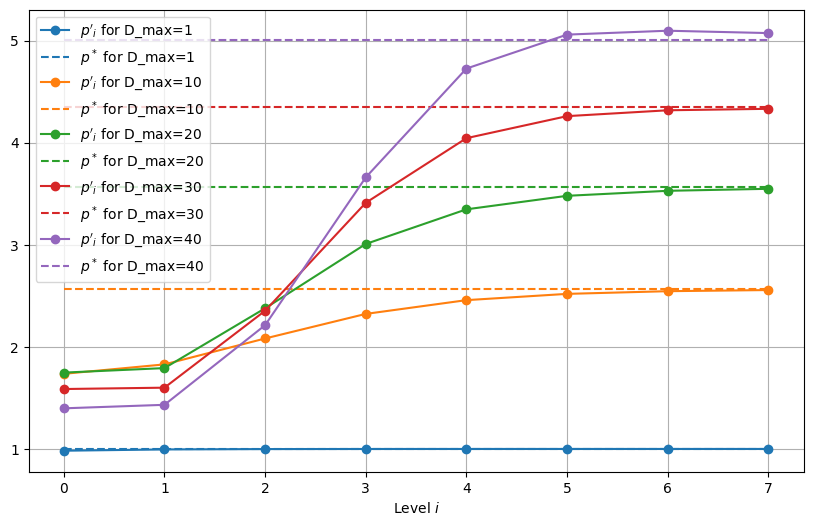

In [7]:
# Plotting p = 1/chi

range_end = 8

plt.figure(figsize=(10, 6))
for D_max in [1, 10, 20, 30, 40]:
    levels = Data_dict[D_max]["levels"][:range_end]  # Only plot for levels 0 to 5
    chi_values = Data_dict[D_max]["chi"][:range_end]  # Corresponding chi values
    line, = plt.plot(levels, 1/np.array(chi_values), marker='o', label=f'$p\'_i$ for D_max={D_max}')
    # Plot theoretical line for each D_max
    theoretical_levels = np.arange(0, range_end)
    theoretical_p = [1/(4/np.pi * np.arctan(np.sqrt(1/D_max))) for _ in theoretical_levels]
    print (theoretical_p)
    print (1/np.array(chi_values))


    plt.plot(theoretical_levels, theoretical_p, linestyle='--', label=f'$p^*$ for D_max={D_max}', color=line.get_color())
plt.xlabel('Level $i$')
plt.legend()
plt.grid()
plt.show()

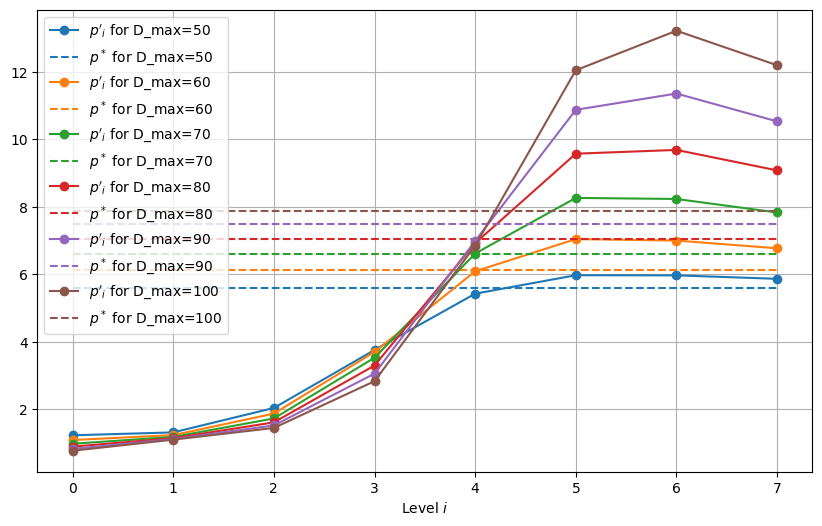

In [9]:
# Plotting p = 1/chi

range_end = 8

plt.figure(figsize=(10, 6))
for D_max in [50, 60, 70, 80, 90, 100]:
    levels = Data_dict[D_max]["levels"][:range_end]  # Only plot for levels 0 to 5
    chi_values = Data_dict[D_max]["chi"][:range_end]  # Corresponding chi values
    line, = plt.plot(levels, 1/np.array(chi_values), marker='o', label=f'$p\'_i$ for D_max={D_max}')
    # Plot theoretical line for each D_max
    theoretical_levels = np.arange(0, range_end)
    theoretical_p = [1/(4/np.pi * np.arctan(np.sqrt(1/D_max))) for _ in theoretical_levels]

    plt.plot(theoretical_levels, theoretical_p, linestyle='--', label=f'$p^*$ for D_max={D_max}', color=line.get_color())
plt.xlabel('Level $i$')
plt.legend()
plt.grid()
plt.show()

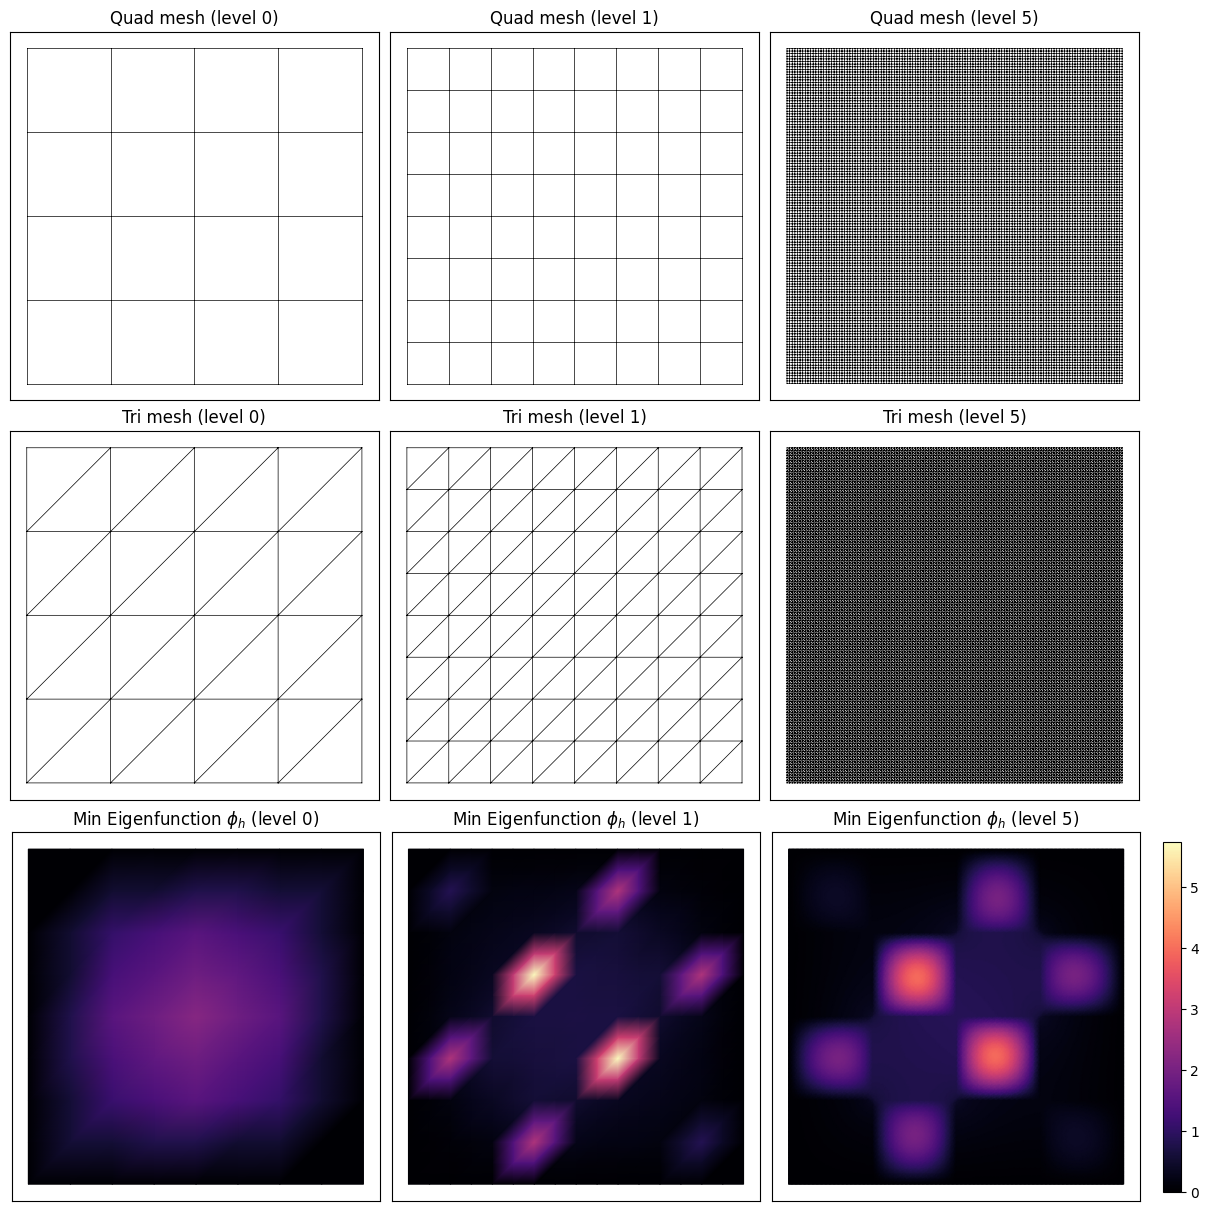

In [24]:
import numpy as np
import matplotlib.pyplot as plt

from skfem import MeshTri, Basis
from skfem.element import ElementTriP1
from skfem.visuals.matplotlib import plot
from skfem.mesh import MeshQuad

xs = np.linspace(0, 1, 5)
ys = np.linspace(0, 1, 5)

def fix_sign(u):
    j = np.argmax(np.abs(u))
    return u if u[j] >= 0 else -u

levels = [0, 1, 5]

# ---- Global color scale (shared across all solution plots) ----
u_list = [fix_sign(Data_dict[100]["u_full"][lvl]) for lvl in levels]
vmin = min(np.min(u) for u in u_list)
vmax = max(np.max(u) for u in u_list)

fig, axes = plt.subplots(3, 3, figsize=(12, 12), constrained_layout=True)

last_mappable = None

for col, level in enumerate(levels):
    m_tri = MeshTri().init_tensor(xs, ys).refined(level)
    m_quad = MeshQuad().init_tensor(xs, ys).refined(level)

    # Row 1: quad meshes
    ax = axes[0, col]
    m_quad.draw(ax=ax)
    ax.set_aspect('equal')
    ax.set_title(f"Quad mesh (level {level})")
    ax.set_xticks([]); ax.set_yticks([])

    # Row 2: tri meshes
    ax = axes[1, col]
    m_tri.draw(ax=ax)
    ax.set_aspect('equal')
    ax.set_title(f"Tri mesh (level {level})")
    ax.set_xticks([]); ax.set_yticks([])

    # Row 3: solutions
    ax = axes[2, col]
    basis = Basis(m_tri, ElementTriP1(), intorder=2)
    u = fix_sign(Data_dict[100]["u_full"][level])

    # skfem.plot returns an Axes; use colorbar=False and extract the mappable afterwards
    plot(
        basis, u,
        ax=ax,
        shading='gouraud',
        cmap='magma',
        colorbar=False
    )
    ax.set_aspect('equal')
    ax.set_title(rf"Min Eigenfunction $\phi_h$ (level {level})")
    ax.set_xticks([]); ax.set_yticks([])

    # Extract the mappable (usually the last collection added)
    if ax.collections:
        m = ax.collections[-1]
    elif ax.images:
        m = ax.images[-1]
    else:
        raise RuntimeError("Couldn't find a mappable artist on the solution axes.")

    # Enforce shared color limits
    m.set_clim(vmin, vmax)
    last_mappable = m

# One shared colorbar for the bottom row
cbar = fig.colorbar(last_mappable, ax=axes[2, :], location='right', shrink=0.95, pad=0.02)

plt.show()


<>:12: SyntaxWarning: invalid escape sequence '\;'
<>:12: SyntaxWarning: invalid escape sequence '\;'
/var/folders/27/l4ch45b92_d1bycgt1sqv5140000gn/T/ipykernel_2108/417780732.py:12: SyntaxWarning: invalid escape sequence '\;'
  plt.title('$|\; \lambda_i - \lambda^*|$ (Log-Log)')


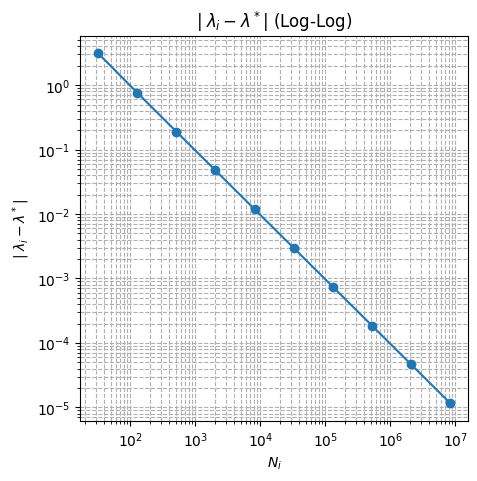

In [10]:
# Computing true rate for D_max = 1


true_lambda1 = 2 * np.pi**2 + 1
errors = [np.abs(Data_dict[1]["lambda1"][i] - true_lambda1) for i in range(len(Data_dict[1]["lambda1"]))] 
elements = [2*4**(2+i) for i in range(len(errors))]
plt.figure(figsize=(5, 5))

plt.loglog(elements, errors, marker='o')
plt.xlabel('$N_i$')
plt.ylabel(r'$| \; \lambda_i - \lambda^*|$')
plt.title('$|\; \lambda_i - \lambda^*|$ (Log-Log)')
plt.grid(True, which="both", ls="--")

plt.show()

In [11]:
# Find the order p such that error ~ DOFs^(-p)
log_dofs = np.log(elements)
log_errors = np.log(errors)
p, _ = np.polyfit(log_dofs, log_errors, 1)
print(f"Estimated convergence order p: {-p:.5f}")

Estimated convergence order p: 1.00132
